# 1. Tokenizer 基本使用

### Cell 1 — 导入 `AutoTokenizer`

**目的**  
`AutoTokenizer` 是 Hugging Face *Transformers* 中负责**自动匹配并实例化分词器类**的入口级 API。  
当你知道模型仓库名称，却不确定该用 `BertTokenizer`、`GPT2Tokenizer` 还是其他专用 Tokenizer 时，使用 `AutoTokenizer` 能自动完成判断并返回正确的分词器对象。

**背景要点**  
- “Auto” 系列（`AutoModel`, `AutoConfig` 等）都遵循同一思想：*名字即入口*。  
- 分词器（Tokenizer）负责把原始文本 ↔ 子词（sub‑word）/id 序列之间的映射，是 NLP 流水线的第一步。  
- 若仓库中同时提供 **fast**（Rust 实现）与 **slow**（纯 Python）版本，`AutoTokenizer` 缺省会优先返回 *fast* 版本，速度更快。



In [39]:
# 导入 AutoTokenizer：万能分词器工厂，根据模型名自动挑选合适的具体 Tokenizer
from transformers import AutoTokenizer


### Cell 2 — 准备示例句子

我们声明一个简单的中文句子放在变量 `sen` 中。  
后面的所有分词、编码、解码示例都会围绕它展开。

In [40]:
# 准备示例中文句子，后续演示都会用到
sen = "搭建大模型网络很简单。"


## Step1 加载与保存

### Cell 3 — 从 Hugging Face Hub 加载中文 RoBERTa 分词器

**关键调用**  
```python
tokenizer = AutoTokenizer.from_pretrained(
    "uer/roberta-base-finetuned-dianping-chinese")
```

- 参数既可以是 *本地目录*，也可以是 *Hub 仓库名*。  
- 首次执行时：  
  1. 客户端检查本地缓存 (`~/.cache/huggingface`)  
  2. 若不存在就从模型 Hub 下载配置文件（`tokenizer.json`, `vocab.txt`, `special_tokens_map.json` …）  
- 返回对象类型：`BertTokenizerFast`（因为底层是 RoBERTa/BERT）。  

调用末尾单独写一个 `tokenizer`，在 Notebook 中可以**直接打印对象配置**以确认加载是否成功。

In [41]:
# 从 Hugging Face Hub 下载并实例化中文 RoBERTa Fast 分词器
tokenizer = AutoTokenizer.from_pretrained("uer/roberta-base-finetuned-dianping-chinese",cache_dir="./06_cache")
# 直接回显对象，Notebook 会友好地展示配置信息
tokenizer


BertTokenizerFast(name_or_path='uer/roberta-base-finetuned-dianping-chinese', vocab_size=21128, model_max_length=1000000000000000019884624838656, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

### Cell 4 — 将分词器保存到本地

`save_pretrained("./roberta_tokenizer")` 会在目标文件夹生成完整的分词器所需文件，方便：

1. 离线环境部署  
2. 自己微调词表后固化版本  
3. 与团队成员共享而不必每次都联网下载

In [42]:
# 将分词器配置及词表保存到本地目录，方便离线/共享
tokenizer.save_pretrained("./roberta_tokenizer")


('./roberta_tokenizer\\tokenizer_config.json',
 './roberta_tokenizer\\special_tokens_map.json',
 './roberta_tokenizer\\vocab.txt',
 './roberta_tokenizer\\added_tokens.json',
 './roberta_tokenizer\\tokenizer.json')

### Cell 5 — 从本地路径再次加载

验证上一 Cell 保存的分词器：只要把 `from_pretrained` 的参数换成本地文件夹路径即可。  
对象的配置、词表大小等信息都应保持一致。

In [43]:
# 从本地路径加载分词器，验证保存成功
tokenizer = AutoTokenizer.from_pretrained("./roberta_tokenizer/")
tokenizer


BertTokenizerFast(name_or_path='./roberta_tokenizer/', vocab_size=21128, model_max_length=1000000000000000019884624838656, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

## Step2 句子分词

### Cell 6 — 基础分词：`tokenizer.tokenize`

- 直接返回子词序列（**不含特殊符号**）。  
- 对中文而言，BERT 系列一般按*字*切分，英文则采用 WordPiece。  
- 观察切分结果有助于理解模型是如何“看待”原句子的。

In [44]:
# 用 tokenize() 查看子词切分结果（不含特殊符号）
tokens = tokenizer.tokenize(sen)
tokens


['搭', '建', '大', '模', '型', '网', '络', '很', '简', '单', '。']

## Step3 查看词典

### Cell 7 — 查看完整词表 `tokenizer.vocab`

打印词表（`dict[token→id]`）能帮助：

* 检查某个新词是否已在词表内  
* 了解特殊符号（`[CLS]`, `[SEP]`, `[PAD]`）的编号  
* 粗看词表大小

In [45]:
# 打印词表字典 (token -> id)
tokenizer.vocab


{'隕': 7393,
 'exe': 9464,
 '孳': 2117,
 '##beth': 12101,
 '##瑣': 17508,
 '独': 4324,
 '蛆': 6025,
 'seo': 8475,
 '##ンター': 11223,
 '##笛': 18070,
 '##鑑': 20198,
 '##罹': 18452,
 '##诊': 19459,
 '##鋰': 20141,
 '##奔': 15001,
 'belle': 13058,
 '##逊': 19906,
 '來': 889,
 '##↑': 10839,
 '学': 2110,
 '##ᵍ': 13491,
 '昔': 3212,
 '##册': 14142,
 '沒': 3760,
 '邁': 6914,
 '今': 791,
 '##城': 14871,
 '##疝': 17605,
 '芍': 5693,
 '##6': 8158,
 '裙': 6170,
 '##增': 14929,
 '##蕩': 18996,
 '##love': 12564,
 'secret': 11634,
 'ir': 12410,
 '纲': 5286,
 '##絵': 18246,
 '##嗯': 14695,
 '##萼': 18918,
 'tcs': 10363,
 'mastercard': 9841,
 '曦': 3286,
 '##聯': 18531,
 '##靚': 20532,
 'so': 8968,
 '苛': 5729,
 '341': 12117,
 '超': 6631,
 '键': 7241,
 '##沿': 16841,
 'yam': 8107,
 'think': 12553,
 '硕': 4798,
 '趁': 6630,
 '##魷': 20856,
 '##桁': 16480,
 'ﾙ': 8096,
 '111': 8932,
 '邇': 6918,
 '##擲': 16153,
 'suv': 8540,
 '饒': 7641,
 '##墻': 14935,
 'daniel': 9701,
 '戕': 2771,
 '衔': 6124,
 '##摁': 16085,
 'yumi': 11697,
 '##斫': 16226,
 '##許': 1

### Cell 8 — 词表大小 `tokenizer.vocab_size`

直接给出词表 token 数（含 special tokens）。  
微调或扩充词表后应核对该值是否符合预期。

In [46]:
# 查看词表大小
tokenizer.vocab_size


21128

## Step4 索引转换

### Cell 9 — Token → ID 低级转换

`convert_tokens_to_ids(tokens)`  
- 在需要自定义分词流程（手工修改 token 列表）时非常有用。  
- 返回列表长度与输入 `tokens` 一致，每个 token 转为整数 ID。

In [47]:
# 将 token 列表映射为 id 列表
ids = tokenizer.convert_tokens_to_ids(tokens)
ids


[3022, 2456, 1920, 3563, 1798, 5381, 5317, 2523, 5042, 1296, 511]

### Cell 10 — ID → Token 反向映射

`convert_ids_to_tokens(ids)`  
- 常用于模型推理后，把输出的 ID 序列转换成人类可读 token。  
- 若要去掉特殊符号可手动过滤或使用 `skip_special_tokens=True`。

In [48]:
# 将 id 列表转换回 token
tokens = tokenizer.convert_ids_to_tokens(ids)
tokens


['搭', '建', '大', '模', '型', '网', '络', '很', '简', '单', '。']

### Cell 11 — Token 序列 → 字符串

`convert_tokens_to_string(tokens)`  
把子词序列重新拼接成可阅读文本。  
⚠️ 对中文分词器而言通常 **不会自动处理空格**；所以看到的返回结果与原句子在空格位置可能略有不同。

In [49]:
# 将 token 序列拼接为可读字符串
str_sen = tokenizer.convert_tokens_to_string(tokens)
str_sen


'搭 建 大 模 型 网 络 很 简 单 。'

###  更便捷的实现方式

### Cell 12 — 高阶接口 `encode`

`encode(sen, add_special_tokens=True)` 会：  

1. 自动在首尾加 `[CLS]`、`[SEP]`  
2. 返回 **ID 序列**，直接可送入模型  
3. 可通过 `return_tensors="pt"` 直接得到 PyTorch 张量

In [50]:
# encode：一步完成分词、映射并添加特殊符号
ids = tokenizer.encode(sen, add_special_tokens=True)
ids


[101, 3022, 2456, 1920, 3563, 1798, 5381, 5317, 2523, 5042, 1296, 511, 102]

### Cell 13 — 高阶接口 `decode`

`decode(ids, skip_special_tokens=False)`  
- 把 ID 序列还原为文本  
- 当 `skip_special_tokens=False` 时可以看到 `[CLS]`、`[SEP]` 等符号在什么位置  
- 对调试编码/解码流程极有帮助

In [51]:
# decode：将 id 序列还原文本
str_sen = tokenizer.decode(ids, skip_special_tokens=False)
str_sen


'[CLS] 搭 建 大 模 型 网 络 很 简 单 。 [SEP]'

## Step5 填充与截断

### Cell 14 — Padding 示例

`encode(..., padding="max_length", max_length=15)`  
- 生成定长输入，长度不足部分补 `[PAD]` (id=0)  
- 适合批量推理或固定形状的硬件 (e.g. TPU/NPU)

In [52]:
# encode 并填充到定长 15
ids = tokenizer.encode(sen, padding="max_length", max_length=15)
ids


[101,
 3022,
 2456,
 1920,
 3563,
 1798,
 5381,
 5317,
 2523,
 5042,
 1296,
 511,
 102,
 0,
 0]

### Cell 15 — Truncation 示例

`encode(..., max_length=5, truncation=True)`  
- 当句子超过 `max_length` 时自动截断  
- 默认截掉末尾；也可通过 `truncation_strategy` 改成头截断或中间截断

In [53]:
# encode + 截断为长度 5
ids = tokenizer.encode(sen, max_length=5, truncation=True)
ids


[101, 3022, 2456, 1920, 102]

## Step6 其他输入部分

### Cell 16 — 再次 Padding：为手工 Mask 做准备

我们再次得到定长 `ids`，随后手工构造 `attention_mask` 与 `token_type_ids`。

In [54]:
# 再次生成定长序列，为手工 Mask 做准备
ids = tokenizer.encode(sen, padding="max_length", max_length=15)
ids


[101,
 3022,
 2456,
 1920,
 3563,
 1798,
 5381,
 5317,
 2523,
 5042,
 1296,
 511,
 102,
 0,
 0]

### Cell 17 — 手工构造 Mask / Segment

- **`attention_mask`**：`1` 表示该 token 参与计算，`0` 表示被 Mask（通常是 `[PAD]`）。  
- **`token_type_ids`**：BERT 用来区分句子 A/B；单句任务时全 0 即可。

In [55]:
# 手动创建 attention_mask：非 PAD 位置标 1
attention_mask = [1 if idx != 0 else 0 for idx in ids]
# 单句任务，token_type_ids 可全 0
token_type_ids = [0] * len(ids)
(ids, attention_mask, token_type_ids)


([101,
  3022,
  2456,
  1920,
  3563,
  1798,
  5381,
  5317,
  2523,
  5042,
  1296,
  511,
  102,
  0,
  0],
 [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

## Step7 快速调用方式

### Cell 18 — `encode_plus`（旧接口）

一次性返回完整字典：`input_ids`, `attention_mask`, `token_type_ids` …  
虽然功能全面，但官方推荐直接使用 `tokenizer()` —— 会根据输入类型智能路由到类似逻辑。

In [56]:
# encode_plus：一次性输出字典形式的多个字段
inputs = tokenizer.encode_plus(sen, padding="max_length", max_length=15)
inputs


{'input_ids': [101, 3022, 2456, 1920, 3563, 1798, 5381, 5317, 2523, 5042, 1296, 511, 102, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]}

### Cell 19 — `tokenizer()` 最简用法

直接把 `sen` 传进去，指定 `padding`/`max_length` 参数，返回 PyTorch/NumPy/原生列表三种格式之一。

In [57]:
# 推荐的 tokenizer() 调用，内部会根据输入类型自动路由
inputs = tokenizer(sen, padding="max_length", max_length=15)
inputs


{'input_ids': [101, 3022, 2456, 1920, 3563, 1798, 5381, 5317, 2523, 5042, 1296, 511, 102, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]}

## Step8 处理batch数据

### Cell 20 — 批量编码

`tokenizer(sens)`：  
- 输入一个 **字符串列表**，返回带批次维度的张量/列表  
- 底层自动对齐填充到最大句长

In [58]:
# 准备 3 条句子，演示批量编码
sens = ["搭建大模型网络很简单。",
        "良好的数学基础有助于理解人工智能模型。",
        "动手实践和理论基础一样重要。"]
res = tokenizer(sens)
res


{'input_ids': [[101, 3022, 2456, 1920, 3563, 1798, 5381, 5317, 2523, 5042, 1296, 511, 102], [101, 5679, 1962, 4638, 3144, 2110, 1825, 4794, 3300, 1221, 754, 4415, 6237, 782, 2339, 3255, 5543, 3563, 1798, 511, 102], [101, 1220, 2797, 2141, 6664, 1469, 4415, 6389, 1825, 4794, 671, 3416, 7028, 6206, 511, 102]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}

### Cell 21 — `%time` 魔法：单条文本循环 1,000 次 Benchmark

通过 `for` 循环把 **同一句文本** 编码 1,000 次，观察 Fast Tokenizer 单条调用的平均耗时。

In [59]:
# %%time -- Benchmark 单条循环 1,000 次
%time
# 逐条处理句子
for i in range(1000):
    tokenizer(sen)


CPU times: total: 0 ns
Wall time: 0 ns


### Cell 22 — `%%time` 魔法：批量 1,000 条文本 Benchmark

直接一次性把 1,000 条相同文本作为列表喂给分词器，测试批量路径的效率。

In [60]:
# %%time -- Benchmark 批量 1,000 条
%time
res = tokenizer([sen] * 1000)


CPU times: total: 0 ns
Wall time: 0 ns


### Cell 23 — 再次打印分词器对象

确保当前使用的仍是 **Fast 版本**，并查看其词表大小、special tokens 等配置。

In [61]:
# 打印当前 tokenizer 对象
tokenizer


BertTokenizerFast(name_or_path='./roberta_tokenizer/', vocab_size=21128, model_max_length=1000000000000000019884624838656, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

# Fast / Slow Tokenizer

### Cell 24 — 重新声明混合语言句子 `sen`

包含中文、英文及感叹号，便于对比 *fast* / *slow* Tokenizer 对 Unicode 处理的差异。

In [62]:
# 定义包含中英混合的新句子
sen = "今天天气非常的nice"


### Cell 25 — 加载 **Fast** 版 Tokenizer

默认 `use_fast=True`，内部采用 Rust 实现，速度大幅优于 *slow* 版。

In [63]:
# 加载 Fast 版本分词器（Rust 实现）
fast_tokenizer = AutoTokenizer.from_pretrained("uer/roberta-base-finetuned-dianping-chinese")
fast_tokenizer


BertTokenizerFast(name_or_path='uer/roberta-base-finetuned-dianping-chinese', vocab_size=21128, model_max_length=1000000000000000019884624838656, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

### Cell 26 — 加载 **Slow** 版 Tokenizer

通过 `use_fast=False` 强制返回纯 Python 实现，方便做速度对比或调试分词行为差异。

In [64]:
# 加载 Slow 版本分词器（纯 Python 实现）
# 给变量 `slow_tokenizer` 赋值
slow_tokenizer = AutoTokenizer.from_pretrained("uer/roberta-base-finetuned-dianping-chinese", use_fast=False,cache_dir="./06_cache")
# 执行操作
slow_tokenizer


BertTokenizer(name_or_path='uer/roberta-base-finetuned-dianping-chinese', vocab_size=21128, model_max_length=1000000000000000019884624838656, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

### Cell 27 — 单条文本循环：Fast Tokenizer 性能测试

In [65]:
# %%time -- Fast Tokenizer 单条循环 10,000 次
import time

start = time.time()
for i in range(10000):
    fast_tokenizer(sen)
end = time.time()
print(f"Elapsed: {end - start:.4f} seconds")


Elapsed: 0.3098 seconds


### Cell 28 — 单条文本循环：Slow Tokenizer 性能测试

In [66]:
# %%time -- Slow Tokenizer 单条循环 10,000 次
start = time.time()
for i in range(10000):
    slow_tokenizer(sen)
end = time.time()
print(f"Elapsed: {end - start:.4f} seconds")

Elapsed: 0.9289 seconds


### Cell 29 — 批量文本：Fast Tokenizer 性能测试

In [67]:
# %%time -- Fast Tokenizer 批量 10,000 条
start = time.time()
res = fast_tokenizer([sen] * 10000)
end = time.time()
print(f"Elapsed: {end - start:.4f} seconds")

Elapsed: 0.1400 seconds


### Cell 30 — 批量文本：Slow Tokenizer 性能测试

In [68]:
# %%time -- Slow Tokenizer 批量 10,000 条
start = time.time()
res = slow_tokenizer([sen] * 10000)
end = time.time()
print(f"Elapsed: {end - start:.4f} seconds")


Elapsed: 0.7529 seconds


`fast_tokenizer(sen, return_offsets_mapping=True)`：

* 将字符串 sen 拆分为子词（sub-word）并编码为 input_ids + attention_mask。

* return_offsets_mapping=True 会额外返回每个子词在原文中的字符区间 (start, end)，方便把模型输出映射回原始文本。

* 把结果存入 inputs，你就能用 inputs["input_ids"]、inputs["offset_mapping"] 等进行模型输入或后处理。

In [69]:
# 给变量 `inputs` 赋值
inputs = fast_tokenizer(sen, return_offsets_mapping=True)
# 执行操作
inputs

{'input_ids': [101, 791, 1921, 1921, 3698, 7478, 2382, 4638, 10192, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'offset_mapping': [(0, 0), (0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 11), (0, 0)]}

`inputs.word_ids()`（FastTokenizer 专有方法）

* 返回一个与 input_ids 等长的列表，每个位置对应原始输入中的“词”索引（或 None）。

* 相同词的各个子词（sub-word）片段会映射到同一个整数词 ID，方便你把 token 级别的预测（如标签）聚合回原始单词。

In [70]:
# 执行操作
inputs.word_ids()

[None, 0, 1, 2, 3, 4, 5, 6, 7, None]

# 2. 模型加载与保存

* AutoConfig：自动加载模型的配置（架构参数、超参等），用于控制模型结构或在自定义场景中修改默认配置。

* AutoModel：根据给定的预训练仓库名称，自动实例化对应的基础模型（不含头部）。

* AutoTokenizer：自动选择并实例化与模型匹配的分词器，用于文本 ↔ token ID 的相互转换。

In [71]:
# 从模块 transformers 导入内容
from transformers import AutoConfig, AutoModel, AutoTokenizer

## 在线加载

`AutoModel.from_pretrained("hfl/rbt3")`：

* 自动从 Hugging Face Hub 下载并实例化仓库名为 hfl/rbt3 的预训练基础模型（仅包含主干 Transformer 层）。

* hfl/rbt3 是华为 Noah’s Ark 团队发布的轻量级中文 RoBERTa 变种。

`force_download=True`：

* 即使本地已有缓存，也强制重新从远端下载最新权重。

* 常用于保证拿到最新更新、或清除损坏的本地缓存。

In [72]:
# 给变量 `model` 赋值
model = AutoModel.from_pretrained("hfl/rbt3", force_download=True,cache_dir="./06_cache")

config.json:   0%|          | 0.00/828 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/828 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/156M [00:00<?, ?B/s]

## 模型下载（需要科学）

**目的**

* 将 Hugging Face 上 hfl/rbt3 仓库的所有文件（包括配置、权重、tokenizer 定义等）下载到当前工作目录，使其成为一个本地 Git 仓库。

**要点**

* Notebook 中以 ! 开头的命令会在系统 shell 中执行，而不是在 Python 里运行。

* 该命令会在当前路径下创建一个名为 rbt3 的文件夹，包含模型权重（通常使用 Git LFS 存储）及 README、config.json、tokenizer.json 等资源。

* 如果想更新本地仓库，可以在该目录内使用标准的 git pull 操作。

In [73]:
# 执行操作
!git clone "https://huggingface.co/hfl/rbt3"

Cloning into 'rbt3'...
Filtering content:  66% (2/3)
Filtering content:  66% (2/3), 293.72 MiB | 153.93 MiB/s
Filtering content: 100% (3/3), 293.72 MiB | 153.93 MiB/s
Filtering content: 100% (3/3), 442.86 MiB | 167.55 MiB/s
Filtering content: 100% (3/3), 442.86 MiB | 2.06 MiB/s, done.
fatal: active `post-checkout` hook found during `git clone`:
	D:/work/ai_course/01_presentations/07_SFT/rbt3/.git/hooks/post-checkout
For security reasons, this is disallowed by default.
If this is intentional and the hook should actually be run, please
run the command again with `GIT_CLONE_PROTECTION_ACTIVE=false`
You can inspect what was checked out with 'git status'
and retry with 'git restore --source=HEAD :/'



In [74]:
# 给变量 `!git lfs clone "https://huggingface.co/hfl/rbt3" --include` 赋值
!git lfs clone "https://huggingface.co/hfl/rbt3" --include="*.bin"

          with new flags from `git clone`

`git clone` has been updated in upstream Git to have comparable
speeds to `git lfs clone`.
fatal: destination path 'rbt3' already exists and is not an empty directory.
Error(s) during clone:
`git clone` failed: exit status 128


## 离线加载

**作用**

* 从当前工作目录下名为 rbt3 的本地文件夹加载预训练模型及其配置。

* 如果本地不存在该目录，from_pretrained("rbt3") 会尝试将其视为 Hugging Face Hub 上的模型 ID。

**注意**

* 确保之前已通过 git clone https://huggingface.co/hfl/rbt3 或者 save_pretrained 将模型保存在 ./rbt3。

* 本地加载避免了网络请求，更适合离线或内网环境。

In [75]:
# 给变量 `model` 赋值
model = AutoModel.from_pretrained("rbt3")

## 模型加载参数

**作用**

* model.config 返回当前加载模型的配置对象（PretrainedConfig 子类）。

* 配置对象包含模型结构和超参数，例如：

  * hidden_size（隐藏层维度）

  * num_attention_heads（注意力头数量）

  * num_hidden_layers（Transformer 层数）

  * vocab_size（词表大小）

  * 以及各类初始化和正则化参数

In [76]:
# 执行操作
model.config

BertConfig {
  "_attn_implementation_autoset": true,
  "_name_or_path": "rbt3",
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "directionality": "bidi",
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 3,
  "output_past": true,
  "pad_token_id": 0,
  "pooler_fc_size": 768,
  "pooler_num_attention_heads": 12,
  "pooler_num_fc_layers": 3,
  "pooler_size_per_head": 128,
  "pooler_type": "first_token_transform",
  "position_embedding_type": "absolute",
  "transformers_version": "4.47.1",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 21128
}

* `AutoConfig.from_pretrained("./rbt3/")`：从本地 ./rbt3/ 目录加载模型的配置文件 config.json，生成一个 PretrainedConfig 对象。

* 直接写 config 会在交互环境中打印该配置，便于检查各项参数。

In [77]:
# 给变量 `config` 赋值
config = AutoConfig.from_pretrained("./rbt3/")
# 执行操作
config

BertConfig {
  "_name_or_path": "./rbt3/",
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "directionality": "bidi",
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 3,
  "output_past": true,
  "pad_token_id": 0,
  "pooler_fc_size": 768,
  "pooler_num_attention_heads": 12,
  "pooler_num_fc_layers": 3,
  "pooler_size_per_head": 128,
  "pooler_type": "first_token_transform",
  "position_embedding_type": "absolute",
  "transformers_version": "4.47.1",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 21128
}

**作用**  
- `output_attentions` 是一个布尔型配置，用于控制模型在前向计算时是否返回每一层的注意力权重张量。  
- 如果设置为 `True`，模型输出将包含一个长度等于 Transformer 层数的列表，列表中每个张量形状为 `(batch_size, num_heads, seq_len, seq_len)`。

**用途**  
- **可视化分析**：查看各层注意力分布，帮助理解模型关注了哪些 token 之间的关联。  
- **调试与解释**：在排查问题或做模型可解释性研究时，辅助定位模型决策依据。  
- **下游应用**：在可解释推荐、关系抽取等高级任务中，可直接利用注意力权重作为特征输入。  


In [78]:
# 执行操作
config.output_attentions

False

# 模型调用

**作用**

* 定义待处理的中文句子 sen，并使用与模型匹配的 AutoTokenizer 将其转换为模型可接受的输入张量。

* return_tensors="pt" 指定返回 PyTorch 张量格式，包含 input_ids 和 attention_mask 两个字段。

**用途**

* 模型推理：将 inputs 中的张量直接送入 model(**inputs)，完成前向计算。

* 调试检查：在交互环境中输出 inputs，可快速验证编码是否符合预期（长度、填充、mask）。

* 下游处理：结合 inputs 可获取 token 索引、注意力掩码等，用于分析、可视化或进一步任务（如序列标注、文本分类）。

In [79]:
# 给变量 `sen` 赋值
sen = "大模型有很多分支。"
# 给变量 `tokenizer` 赋值
tokenizer = AutoTokenizer.from_pretrained("rbt3")
# 给变量 `inputs` 赋值
inputs = tokenizer(sen, return_tensors="pt")
# 执行操作
inputs

{'input_ids': tensor([[ 101, 1920, 3563, 1798, 3300, 2523, 1914, 1146, 3118,  511,  102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

## 不带Model Head的模型调用


* output_attentions=True：在模型前向计算时，额外返回每层的注意力权重张量。

In [80]:
# 给变量 `model` 赋值
model = AutoModel.from_pretrained("rbt3", output_attentions=True)

作用
* 调用模型的 forward 方法，将预先编码好的 inputs（包含 input_ids、attention_mask，如果开启了还会有 output_attentions）传入模型。

* 返回一个包含模型输出的对象，通常包括：

  * last_hidden_state：最后一层的隐藏向量张量

  * pooler_output（若存在）或 logits（若为分类/回归头）

  * attentions（如果 output_attentions=True，则包含各层的注意力权重）

用途
* 获取模型表示：使用 output.last_hidden_state 提取每个 token 的上下文向量，用于序列标注、嵌入提取等下游任务。

* 分类/回归：若加载了带头模型，可直接从 output.logits 获取分类或回归结果。

* 可视化与分析：结合 output.attentions（如有）分析模型的注意力分布，辅助可解释性研究。

In [81]:
# 给变量 `output` 赋值
output = model(**inputs)
# 执行操作
output

BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


BaseModelOutputWithPoolingAndCrossAttentions(last_hidden_state=tensor([[[ 0.4751,  1.0386,  0.8247,  ..., -0.0433,  0.4502,  0.2970],
         [-0.7249,  0.5157, -0.5889,  ..., -0.2965,  0.0679, -0.3155],
         [-0.5304,  0.0444, -0.3814,  ..., -0.6709, -0.1767, -0.3287],
         ...,
         [ 0.4477,  0.3814,  0.3337,  ...,  0.0437,  0.4791, -0.0869],
         [-0.0772,  0.3630,  0.0988,  ..., -0.4886,  0.0920, -0.3146],
         [ 0.4675,  1.0394,  0.8186,  ..., -0.0385,  0.4445,  0.2986]]],
       grad_fn=<NativeLayerNormBackward0>), pooler_output=tensor([[ 2.8643e-02, -9.9207e-01, -1.0000e+00, -8.5681e-01,  6.7209e-01,
         -6.0775e-02, -3.1940e-01, -2.0260e-01,  9.8484e-01,  9.9997e-01,
         -1.6088e-02, -1.0000e+00, -2.2830e-01,  9.9954e-01, -1.0000e+00,
          9.9992e-01,  9.7195e-01,  9.8815e-01, -9.9954e-01, -5.0331e-02,
         -9.7277e-01, -1.3380e-01,  2.4541e-01,  9.9489e-01,  9.9934e-01,
         -9.9904e-01, -9.9999e-01, -2.0023e-01, -9.6294e-01, -9.999

* 调用 PyTorch 张量的 .size() 方法，返回 last_hidden_state 的形状信息，类型为 torch.Size。

* 对于 BERT 类模型，通常形状为 (batch_size, seq_len, hidden_size)。

In [82]:
# 执行操作
output.last_hidden_state.size()

torch.Size([1, 11, 768])

* 计算第一个样本的 input_ids 列表长度，即模型输入序列（包括特殊标记）的 token 数量。

In [83]:
# 执行操作
len(inputs["input_ids"][0])

11

## 带Model Head的模型调用

`AutoModelForSequenceClassification`：根据预训练模型 ID 自动选择并实例化对应的带分类头的模型。

In [84]:
# 从模块 transformers 导入内容
from transformers import AutoModelForSequenceClassification

作用
* 使用 AutoModelForSequenceClassification 从本地或 Hugging Face Hub 中加载 rbt3 模型，并在其顶部附加一个线性分类头。

* 参数 num_labels=10 指定分类头的输出维度为 10，用于多分类任务。

用途
* 多分类任务：直接对输入文本执行 10 类别的分类，如主题分类、意图识别等。

* 快速上手：一行代码即可完成模型结构与分类头的初始化，免去手动拼接网络的繁琐。

* Fine-tuning：可直接将 clz_model 与 Trainer 或自定义训练循环结合，对特定数据集进行微调。

In [85]:
# 给变量 `clz_model` 赋值
clz_model = AutoModelForSequenceClassification.from_pretrained("rbt3", num_labels=10)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at rbt3 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


* 将预先编码好的 inputs 喂入带分类头的模型，执行前向计算。

* 返回一个包含 logits 的输出对象，形状为 (batch_size, num_labels)，对应每个样本对 10 个类别的打分。

In [86]:
# 执行操作
clz_model(**inputs)

SequenceClassifierOutput(loss=None, logits=tensor([[-0.3979, -0.0988,  0.0270, -0.4427,  0.0679, -0.4411, -0.1793, -0.0632,
          0.1968, -1.1030]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)

* 读取当前分类模型 (clz_model) 的配置中 num_labels 字段，返回分类头的标签数量（此处应为 10）。

In [87]:
# 执行操作
clz_model.config.num_labels

10

In [88]:
# 从模块 datasets 导入内容
from datasets import *

# 3. datasets 基本使用

作用
* datasets 是 Hugging Face 提供的高效数据集管理与处理库，支持从多种来源（本地文件、Hugging Face Hub、JSON/CSV、文本、Arrow、SQL 等）一行代码加载和共享数据集。

* from datasets import * 会导入常用 API：

  * load_dataset：加载已发布的数据集或本地数据文件

  * Dataset, DatasetDict：操作单一或分割后（train/validation/test）的数据集对象

  * load_metric：便捷地获取标准评估指标（如 accuracy、bleu、rouge）

  * 以及通用的 Features, Value, ClassLabel 等类型声明工具

## 加载在线数据集

* load_dataset("madao33/new-title-chinese") 从 Hugging Face Hub 加载由用户 madao33 发布的 “new-title-chinese” 数据集。

* 返回一个 DatasetDict 对象，通常包含若干数据拆分（如 train、validation、test），以及每个拆分下的数据示例和字段信息。

In [89]:
# 给变量 `datasets` 赋值
datasets = load_dataset("madao33/new-title-chinese",cache_dir="./06_cache")
# 执行操作
datasets

Generating train split:   0%|          | 0/5850 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1679 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['title', 'content'],
        num_rows: 5850
    })
    validation: Dataset({
        features: ['title', 'content'],
        num_rows: 1679
    })
})

## 加载数据集合集中的某一项任务

作用
* 使用 load_dataset("super_glue", "boolq", trust_remote_code=True) 从 Hugging Face Hub 加载 SuperGLUE 基准中的 BoolQ（布尔式问答）任务数据集。

* trust_remote_code=True 允许在加载时执行数据集仓库中的自定义脚本（例如特殊的解析或预处理逻辑）。

用途
* 任务验证：BoolQ 是一个二分类问答任务，用来评估模型在理解短文本问答对的能力，可用于测试模型的推理表现。

In [90]:
# 给变量 `boolq_dataset` 赋值
boolq_dataset = load_dataset("super_glue", "boolq",trust_remote_code=True,cache_dir="./06_cache")
# 执行操作
boolq_dataset

Generating train split:   0%|          | 0/9427 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3270 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3245 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['question', 'passage', 'idx', 'label'],
        num_rows: 9427
    })
    validation: Dataset({
        features: ['question', 'passage', 'idx', 'label'],
        num_rows: 3270
    })
    test: Dataset({
        features: ['question', 'passage', 'idx', 'label'],
        num_rows: 3245
    })
})

## 按照数据集划分进行加载

作用
* 使用 split="train" 参数，仅加载 “madao33/new-title-chinese” 数据集的训练集部分，返回一个 Dataset 对象。

* 相比加载全 DatasetDict，可节省内存并直接操作所需拆分。

In [91]:
# 给变量 `dataset` 赋值
dataset = load_dataset("madao33/new-title-chinese", split="train",cache_dir="./06_cache")
# 执行操作
dataset

Dataset({
    features: ['title', 'content'],
    num_rows: 5850
})

* 使用切片语法 train[10:100] 仅加载训练集中的第 10 到第 99 条样本（左闭右开区间），返回一个子集 Dataset 对象。

* 避免一次性载入整个拆分，节省内存并加快交互式调试速度。

In [92]:
# 给变量 `dataset` 赋值
dataset = load_dataset("madao33/new-title-chinese", split="train[10:100]",cache_dir="./06_cache")
# 执行操作
dataset

Dataset({
    features: ['title', 'content'],
    num_rows: 90
})

* 使用切片语法 train[:50%] 只加载训练集中前 50% 的样本，返回一个子集 Dataset 对象。

* 按比例加载可灵活控制数据量，避免一次性读取整个拆分。

In [93]:
# 给变量 `dataset` 赋值
dataset = load_dataset("madao33/new-title-chinese", split="train[:50%]",cache_dir="./06_cache")
# 执行操作
dataset

Dataset({
    features: ['title', 'content'],
    num_rows: 2925
})

In [94]:
# 给变量 `dataset` 赋值
dataset = load_dataset("madao33/new-title-chinese", split=["train[:50%]", "train[50%:]"],cache_dir="./06_cache")
# 执行操作
dataset

[Dataset({
     features: ['title', 'content'],
     num_rows: 2925
 }),
 Dataset({
     features: ['title', 'content'],
     num_rows: 2925
 })]

## 查看数据集

* load_dataset("madao33/new-title-chinese") 从 Hugging Face Hub 一次性加载整个数据集，返回一个 DatasetDict，通常包含 train、validation、test 等拆分。

In [95]:
# 给变量 `datasets` 赋值
datasets = load_dataset("madao33/new-title-chinese",cache_dir="./06_cache")
# 执行操作
datasets

DatasetDict({
    train: Dataset({
        features: ['title', 'content'],
        num_rows: 5850
    })
    validation: Dataset({
        features: ['title', 'content'],
        num_rows: 1679
    })
})

作用
* 直接索引 DatasetDict 中 train 拆分的第 0 号样本，返回一个 Python 字典，包含该样本的所有字段及其值。

用途
* 数据预览：快速查看单条样本的结构与内容（例如文本字段、标签字段等），验证数据加载和字段映射是否正确。

* 调试：在编写预处理或特征抽取函数前，先检查典型样本格式，确保后续操作不会发生键错误或数据类型不匹配。

* 示例提取：可以将这一条作为输入示例，演示模型推理或可视化流程。

In [96]:
# 执行操作
datasets["train"][0]

{'title': '望海楼美国打“台湾牌”是危险的赌博',
 'content': '近期，美国国会众院通过法案，重申美国对台湾的承诺。对此，中国外交部发言人表示，有关法案严重违反一个中国原则和中美三个联合公报规定，粗暴干涉中国内政，中方对此坚决反对并已向美方提出严正交涉。\n事实上，中国高度关注美国国内打“台湾牌”、挑战一中原则的危险动向。近年来，作为“亲台”势力大本营的美国国会动作不断，先后通过“与台湾交往法”“亚洲再保证倡议法”等一系列“挺台”法案，“2019财年国防授权法案”也多处触及台湾问题。今年3月，美参院亲台议员再抛“台湾保证法”草案。众院议员继而在4月提出众院版的草案并在近期通过。上述法案的核心目标是强化美台关系，并将台作为美“印太战略”的重要伙伴。同时，“亲台”议员还有意制造事端。今年2月，5名共和党参议员致信众议院议长，促其邀请台湾地区领导人在国会上发表讲话。这一动议显然有悖于美国与台湾的非官方关系，其用心是实质性改变美台关系定位。\n上述动向出现并非偶然。在中美建交40周年之际，两国关系摩擦加剧，所谓“中国威胁论”再次沉渣泛起。美国对华认知出现严重偏差，对华政策中负面因素上升，保守人士甚至成立了“当前中国威胁委员会”。在此背景下，美国将台海关系作为战略抓手，通过打“台湾牌”在双边关系中增加筹码。特朗普就任后，国会对总统外交政策的约束力和塑造力加强。其实国会推动通过涉台法案对行政部门不具约束力，美政府在2018年并未提升美台官员互访级别，美军舰也没有“访问”台湾港口，保持着某种克制。但从美总统签署国会通过的法案可以看出，国会对外交产生了影响。立法也为政府对台政策提供更大空间。\n然而，美国需要认真衡量打“台湾牌”成本。首先是美国应对危机的代价。美方官员和学者已明确发出警告，美国卷入台湾问题得不偿失。美国学者曾在媒体发文指出，如果台海爆发危机，美国可能需要“援助”台湾，进而导致新的冷战乃至与中国大陆的冲突。但如果美国让台湾自己面对，则有损美国的信誉，影响美盟友对同盟关系的支持。其次是对中美关系的危害。历史证明，中美合则两利、斗则两伤。中美关系是当今世界最重要的双边关系之一，保持中美关系的稳定发展，不仅符合两国和两国人民的根本利益，也是国际社会的普遍期待。美国蓄意挑战台湾问题的底线，加剧中美关系的复杂性和不确定性，损害两国在重要领域合作，损人又害己

作用
* 批量索引 train 拆分的前 2 条记录，返回一个列表，每项为一个包含样本字段的字典。

用途
* 快速预览：一次性查看多条样本，帮助了解数据多样性与字段一致性。

* 批量调试：验证对多条示例同时应用预处理或映射函数时的行为是否符合预期。

* Pipeline 演示：以这些示例为输入，演示后续分词、模型推理或可视化流程。

In [97]:
# 执行操作
datasets["train"][:2]

{'title': ['望海楼美国打“台湾牌”是危险的赌博', '大力推进高校治理能力建设'],
 'content': ['近期，美国国会众院通过法案，重申美国对台湾的承诺。对此，中国外交部发言人表示，有关法案严重违反一个中国原则和中美三个联合公报规定，粗暴干涉中国内政，中方对此坚决反对并已向美方提出严正交涉。\n事实上，中国高度关注美国国内打“台湾牌”、挑战一中原则的危险动向。近年来，作为“亲台”势力大本营的美国国会动作不断，先后通过“与台湾交往法”“亚洲再保证倡议法”等一系列“挺台”法案，“2019财年国防授权法案”也多处触及台湾问题。今年3月，美参院亲台议员再抛“台湾保证法”草案。众院议员继而在4月提出众院版的草案并在近期通过。上述法案的核心目标是强化美台关系，并将台作为美“印太战略”的重要伙伴。同时，“亲台”议员还有意制造事端。今年2月，5名共和党参议员致信众议院议长，促其邀请台湾地区领导人在国会上发表讲话。这一动议显然有悖于美国与台湾的非官方关系，其用心是实质性改变美台关系定位。\n上述动向出现并非偶然。在中美建交40周年之际，两国关系摩擦加剧，所谓“中国威胁论”再次沉渣泛起。美国对华认知出现严重偏差，对华政策中负面因素上升，保守人士甚至成立了“当前中国威胁委员会”。在此背景下，美国将台海关系作为战略抓手，通过打“台湾牌”在双边关系中增加筹码。特朗普就任后，国会对总统外交政策的约束力和塑造力加强。其实国会推动通过涉台法案对行政部门不具约束力，美政府在2018年并未提升美台官员互访级别，美军舰也没有“访问”台湾港口，保持着某种克制。但从美总统签署国会通过的法案可以看出，国会对外交产生了影响。立法也为政府对台政策提供更大空间。\n然而，美国需要认真衡量打“台湾牌”成本。首先是美国应对危机的代价。美方官员和学者已明确发出警告，美国卷入台湾问题得不偿失。美国学者曾在媒体发文指出，如果台海爆发危机，美国可能需要“援助”台湾，进而导致新的冷战乃至与中国大陆的冲突。但如果美国让台湾自己面对，则有损美国的信誉，影响美盟友对同盟关系的支持。其次是对中美关系的危害。历史证明，中美合则两利、斗则两伤。中美关系是当今世界最重要的双边关系之一，保持中美关系的稳定发展，不仅符合两国和两国人民的根本利益，也是国际社会的普遍期待。美国蓄意挑战台湾问题的底线，加剧中美关系的复杂性和不确定

作用
* 直接访问 train 拆分中键名为 "title" 的列，并取前 5 条记录，返回一个列表，包含 5 个标题字符串。

用途
* 列级预览：快速查看特定字段（如标题）的内容，判断文本质量与多样性。

* 数据分布分析：了解该字段的常见长度、格式或关键词分布，辅助后续文本清洗和特征工程。

* 示例展示：直接将这些标题作为示例输入，演示分词、模型推理或可视化效果。

In [98]:
# 执行操作
datasets["train"]["title"][:5]

['望海楼美国打“台湾牌”是危险的赌博',
 '大力推进高校治理能力建设',
 '坚持事业为上选贤任能',
 '“大朋友”的话儿记心头',
 '用好可持续发展这把“金钥匙”']

* 返回 train 拆分中所有字段（列）的名称列表，例如 ["title", "text", "label"] 等。

In [99]:
# 执行操作
datasets["train"].column_names

['title', 'content']

* 返回一个 Features 对象，描述 train 拆分中每个字段的类型、形状和可能的取值空间（如 Value, ClassLabel, Sequence 等）。

In [100]:
# 执行操作
datasets["train"].features

{'title': Value(dtype='string', id=None),
 'content': Value(dtype='string', id=None)}

## 数据集划分

* dataset = datasets["train"]：将原始 DatasetDict 的训练拆分取出，赋值给 dataset。

* dataset.train_test_split(test_size=0.1)：在 dataset 上随机抽取 10% 样本作为新测试集，其余 90% 作为新训练集，返回一个包含 train 和 test 两个子拆分的 DatasetDict。

In [101]:
# 给变量 `dataset` 赋值
dataset = datasets["train"]
# 给变量 `dataset.train_test_split(test_size` 赋值
dataset.train_test_split(test_size=0.1)

DatasetDict({
    train: Dataset({
        features: ['title', 'content'],
        num_rows: 5265
    })
    test: Dataset({
        features: ['title', 'content'],
        num_rows: 585
    })
})

* 从 boolq_dataset 中提取 train 拆分，并在该子集上执行 train_test_split。

* stratify_by_column="label" 确保新训练集和测试集中，各类别样本比例与原始数据保持一致，避免类别失衡。

In [102]:
# 给变量 `dataset` 赋值
dataset = boolq_dataset["train"]
# 给变量 `dataset.train_test_split(test_size` 赋值
dataset.train_test_split(test_size=0.1, stratify_by_column="label")     # 分类数据集可以按照比例划分

DatasetDict({
    train: Dataset({
        features: ['question', 'passage', 'idx', 'label'],
        num_rows: 8484
    })
    test: Dataset({
        features: ['question', 'passage', 'idx', 'label'],
        num_rows: 943
    })
})

## 数据选取与过滤

* select([0, 1]) 会返回一个新的 Dataset，仅包含训练集里索引为 0 和 1 的两条记录。

In [103]:
# 选取
# 执行操作
datasets["train"].select([0, 1])

Dataset({
    features: ['title', 'content'],
    num_rows: 2
})

* 使用 filter 方法遍历训练集中的每个样本，保留 title 字段中包含子串 "中国" 的记录，生成新的子集 filter_dataset。

In [104]:
# 过滤
# 给变量 `filter_dataset` 赋值
filter_dataset = datasets["train"].filter(lambda example: "中国" in example["title"])

Filter:   0%|          | 0/5850 [00:00<?, ? examples/s]

* 获取 filter_dataset（仅含标题中包含 “中国” 的样本）中前 5 条的 title 字段值，返回一个字符串列表。

In [105]:
# 执行操作
filter_dataset["title"][:5]

['聚焦两会，世界探寻中国成功秘诀',
 '望海楼中国经济的信心来自哪里',
 '“中国奇迹”助力世界减贫跑出加速度',
 '和音瞩目历史交汇点上的中国',
 '中国风采感染世界']

## 数据映射

* 创建一个接受单条样本（example）的函数，将其 title 字段值前增加固定字符串 "Prefix: "，并返回修改后的样本。

In [106]:
# 定义函数：add_prefix
def add_prefix(example):
    # 给变量 `example["title"]` 赋值
    example["title"] = 'Prefix: ' + example["title"]
    # 执行操作
    return example

* datasets.map(add_prefix)：对 datasets 中所有拆分（如 train、validation 等）批量应用 add_prefix 函数，生成新的 DatasetDict 并赋值给 prefix_dataset。

* prefix_dataset["train"][:10]["title"]：从新增前缀后的训练集里，提取前 10 条样本的 title 列表。

In [107]:
# 给变量 `prefix_dataset` 赋值
prefix_dataset = datasets.map(add_prefix)
# 执行操作
prefix_dataset["train"][:10]["title"]

Map:   0%|          | 0/5850 [00:00<?, ? examples/s]

Map:   0%|          | 0/1679 [00:00<?, ? examples/s]

['Prefix: 望海楼美国打“台湾牌”是危险的赌博',
 'Prefix: 大力推进高校治理能力建设',
 'Prefix: 坚持事业为上选贤任能',
 'Prefix: “大朋友”的话儿记心头',
 'Prefix: 用好可持续发展这把“金钥匙”',
 'Prefix: 跨越雄关，我们走在大路上',
 'Prefix: 脱贫奇迹彰显政治优势',
 'Prefix: 拱卫亿万人共同的绿色梦想',
 'Prefix: 为党育人、为国育才',
 'Prefix: 净化网络语言']

* 加载分词器：使用 AutoTokenizer.from_pretrained("bert-base-chinese") 得到与 bert-base-chinese 模型匹配的分词器。

* 批量编码：在 preprocess_function 中，分别对样本的 content（文本输入）和 title（目标输出）做截断编码，生成模型输入与标签。

In [108]:
# 从模块 transformers 导入内容
from transformers import AutoTokenizer
# 给变量 `tokenizer` 赋值
tokenizer = AutoTokenizer.from_pretrained("bert-base-chinese")
# 定义函数：preprocess_function
def preprocess_function(example, tokenizer=tokenizer):
    # 给变量 `model_inputs` 赋值
    model_inputs = tokenizer(example["content"], max_length=512, truncation=True)
    # 给变量 `labels` 赋值
    labels = tokenizer(example["title"], max_length=32, truncation=True)
    # label就是title编码的结果
    # 给变量 `model_inputs["labels"]` 赋值
    model_inputs["labels"] = labels["input_ids"]
    # 执行操作
    return model_inputs

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

c:\Users\kang\miniconda3\envs\pytorch\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\kang\.cache\huggingface\hub\models--bert-base-chinese. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/624 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/110k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/269k [00:00<?, ?B/s]

* 使用 map(preprocess_function) 对整个 datasets（所有拆分）批量执行 preprocess_function，生成包含编码输入 (input_ids、attention_mask) 及对应标签 (labels) 的新 DatasetDict。

In [109]:
# 给变量 `processed_datasets` 赋值
processed_datasets = datasets.map(preprocess_function)
# 执行操作
processed_datasets

Map:   0%|          | 0/5850 [00:00<?, ? examples/s]

Map:   0%|          | 0/1679 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['title', 'content', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 5850
    })
    validation: Dataset({
        features: ['title', 'content', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 1679
    })
})

* num_proc=4：使用 4 个并行进程加速 map 操作，对数据集进行并行化预处理。

* 返回新的 DatasetDict，包含所有拆分的编码输入与标签字段。

In [110]:
# 给变量 `processed_datasets` 赋值
processed_datasets = datasets.map(preprocess_function, num_proc=4)
# 执行操作
processed_datasets

Map (num_proc=4):   0%|          | 0/5850 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/1679 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['title', 'content', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 5850
    })
    validation: Dataset({
        features: ['title', 'content', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 1679
    })
})

* batched=True：将输入样本按批（默认批大小）传入 preprocess_function，一次处理多个样本，减少 Python 函数调用开销。

* 返回一个新的 DatasetDict，其中每个拆分都已包含批量编码后的 input_ids、attention_mask 和 labels 字段。

In [111]:
# 给变量 `processed_datasets` 赋值
processed_datasets = datasets.map(preprocess_function, batched=True)
# 执行操作
processed_datasets

Map:   0%|          | 0/5850 [00:00<?, ? examples/s]

Map:   0%|          | 0/1679 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['title', 'content', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 5850
    })
    validation: Dataset({
        features: ['title', 'content', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 1679
    })
})

* batched=True：按批将样本送入 preprocess_function，提高预处理效率。

* remove_columns=datasets["train"].column_names： 在映射后删除原数据集的所有原始列，仅保留新生成的 input_ids、attention_mask、labels 等字段。

* 返回一个新的 DatasetDict，其每个拆分只包含模型所需的列。

In [112]:
# 给变量 `processed_datasets` 赋值
processed_datasets = datasets.map(preprocess_function, batched=True, remove_columns=datasets["train"].column_names)
# 执行操作
processed_datasets

Map:   0%|          | 0/5850 [00:00<?, ? examples/s]

Map:   0%|          | 0/1679 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 5850
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 1679
    })
})

## 保存与加载

作用
* 调用 save_to_disk 方法，将 DatasetDict 的所有拆分及其数据序列化并保存到指定目录。

用途
* 持久化存储：将预处理结果保存在本地，避免每次运行都重新映射，提高效率。

* 离线加载：使用 load_from_disk("./processed_data") 可以快速恢复数据集，无需重新联网下载或预处理。

* 团队共享：将保存目录打包或推送到共享存储，其他成员可直接加载并使用相同的数据集版本。

In [113]:
# 执行操作
processed_datasets.save_to_disk("./processed_data")

Saving the dataset (0/1 shards):   0%|          | 0/5850 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1679 [00:00<?, ? examples/s]

* load_from_disk("./processed_data") 读取之前通过 save_to_disk 保存的预处理数据集，恢复成一个完整的 DatasetDict 对象。

* 避免重新下载和预处理，直接获取已序列化的编码后数据。

In [114]:
# 给变量 `processed_datasets` 赋值
processed_datasets = load_from_disk("./processed_data")
# 执行操作
processed_datasets

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 5850
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 1679
    })
})

# 加载本地数据集

## 直接加载文件作为数据集

作用
* 使用 load_dataset("csv", ...) 将指定路径下的 CSV 文件读入为 Hugging Face Dataset；

* split="train" 将其作为单一训练集拆分返回。

用途
* 数据探索：查看 CSV 数据的字段、行数及样本内容，验证正确加载；

* 预处理管道：可直接对 dataset 应用 .map()、.filter() 等操作，进行清洗与特征工程；

* 模型训练：将其作为 Trainer 或自定义 DataLoader 的输入，进行情感分析或其他下游任务微调。

In [116]:
# 给变量 `dataset` 赋值
dataset = load_dataset("csv", data_files="./06_cache/ChnSentiCorp_htl_all.csv", split="train")
# 执行操作
dataset

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['label', 'review'],
    num_rows: 7766
})

作用
* Dataset.from_csv() 是 datasets 库提供的快捷方法，直接读取本地 CSV 文件并转换为一个 Dataset 对象。

* 自动将文件中的列名映射为字段，使用 Apache Arrow 序列化底层数据。

用途
* 快速加载：无需指定 load_dataset("csv", ...) 的额外参数，一行代码完成 CSV → Dataset 的转换。

* 高效处理：底层采用 Arrow 格式，支持零拷贝和高性能批量操作。

* 无缝兼容：加载后可直接对 dataset 应用 .map()、.filter()、.train_test_split() 等方法，接入 Hugging Face 全流程。

In [117]:
# 给变量 `dataset` 赋值
dataset = Dataset.from_csv("./06_cache/ChnSentiCorp_htl_all.csv")
# 执行操作
dataset

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['label', 'review'],
    num_rows: 7766
})

## 加载文件夹内全部文件作为数据集

* 同时读取指定列表中的多个 CSV 文件，并将它们合并成一个统一的 Dataset。

* split="train" 参数将合并后的所有数据视为一个训练拆分返回。

In [119]:
# 给变量 `dataset` 赋值
dataset = load_dataset("csv", data_files=["06_cache/all_data/ChnSentiCorp_htl_all.csv", "06_cache/all_data/ChnSentiCorp_htl_all copy.csv"], split='train')
# 执行操作
dataset

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['label', 'review'],
    num_rows: 15532
})

## 通过预先加载的其他格式转换加载数据集

* 使用 Pandas 从本地 CSV 文件读取数据，生成一个 DataFrame 对象。

* data.head() 展示前五行记录，便于快速检查加载结果及字段名称。

In [120]:
# 导入模块：pandas as pd
import pandas as pd

# 给变量 `data` 赋值
data = pd.read_csv("./06_cache/ChnSentiCorp_htl_all.csv")
# 执行操作
data.head()

,label,review
0,1,"距离川沙公路较近,但是公交指示不对,如果是""蔡陆线""的话,会非常麻烦.建议用别的路线.房间较..."
1,1,商务大床房，房间很大，床有2M宽，整体感觉经济实惠不错!
2,1,早餐太差，无论去多少人，那边也不加食品的。酒店应该重视一下这个问题了。房间本身很好。
3,1,宾馆在小街道上，不大好找，但还好北京热心同胞很多~宾馆设施跟介绍的差不多，房间很小，确实挺小...
4,1,"CBD中心,周围没什么店铺,说5星有点勉强.不知道为什么卫生间没有电吹风"


* 使用 Dataset.from_pandas() 将 Pandas DataFrame 快速转换为 Hugging Face Dataset 对象，底层同样基于 Apache Arrow 存储。

In [121]:
# 给变量 `dataset` 赋值
dataset = Dataset.from_pandas(data)
# 执行操作
dataset

Dataset({
    features: ['label', 'review'],
    num_rows: 7766
})

* Dataset.from_list(data) 会将 Python 列表 data 转为 Hugging Face Dataset，其中每个列表元素必须是字典，字典键表示字段名（此例中为 "text"），值为对应数据。

In [122]:
# List格式的数据需要内嵌{}，明确数据字段
# 给变量 `data` 赋值
data = [{"text": "abc"}, {"text": "def"}]
# data = ["abc", "def"]
# 执行操作
Dataset.from_list(data)

Dataset({
    features: ['text'],
    num_rows: 2
})

## 通过自定义加载脚本加载数据集

作用
* 使用 load_dataset("json", ...) 将本地 JSON 文件读入为 Hugging Face Dataset。

* data_files 指定源文件路径，field="data" 表明顶层键名为 "data"，在该键下提取列表式记录作为样本。

用途
* 结构化解析：自动根据 JSON 的嵌套结构提取所需字段，简化手工解析过程。

* 多场景加载：支持加载带有元信息或嵌套列表的复杂 JSON（如 QA、对话、日志等）。

In [123]:
# 给变量 `load_dataset("json", data_files` 赋值
load_dataset("json", data_files="./06_cache/cmrc2018_trial.json", field="data")

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['paragraphs', 'id', 'title'],
        num_rows: 256
    })
})

* load_dataset("./07_datasets/load_script.py", …)：使用本地 Python 脚本 load_script.py 中定义的数据集加载逻辑，而非内置格式化器。

* split="train"：指定返回脚本中实现的训练拆分（若脚本支持多个拆分）。

* trust_remote_code=True：允许执行脚本里的自定义代码（例如自定义解析函数或数据增强逻辑），确保按作者意图加载数据。

In [124]:
# 给变量 `dataset` 赋值
dataset = load_dataset("./06_cache/load_script.py", split="train",trust_remote_code=True)
# 执行操作
dataset

Dataset({
    features: ['id', 'context', 'question', 'answers'],
    num_rows: 1002
})

In [125]:
# 执行操作
dataset[0]

{'id': 'TRIAL_800_QUERY_0',
 'context': '基于《跑跑卡丁车》与《泡泡堂》上所开发的游戏，由韩国Nexon开发与发行。中国大陆由盛大游戏运营，这是Nexon时隔6年再次授予盛大网络其游戏运营权。台湾由游戏橘子运营。玩家以水枪、小枪、锤子或是水炸弹泡封敌人(玩家或NPC)，即为一泡封，将水泡击破为一踢爆。若水泡未在时间内踢爆，则会从水泡中释放或被队友救援(即为一救援)。每次泡封会减少生命数，生命数耗完即算为踢爆。重生者在一定时间内为无敌状态，以踢爆数计分较多者获胜，规则因模式而有差异。以2V2、4V4随机配对的方式，玩家可依胜场数爬牌位(依序为原石、铜牌、银牌、金牌、白金、钻石、大师) ，可选择经典、热血、狙击等模式进行游戏。若游戏中离，则4分钟内不得进行配对(每次中离+4分钟)。开放时间为暑假或寒假期间内不定期开放，8人经典模式随机配对，采计分方式，活动时间内分数越多，终了时可依该名次获得奖励。',
 'question': '生命数耗完即算为什么？',
 'answers': {'text': ['踢爆'], 'answer_start': [127]}}

# Dataset with DataCollator

作用
* DataCollatorWithPadding 是一个数据整理器（data collator），用于在批量构建时动态地将不同长度的输入序列统一填充到当前批次中最长序列的长度。

* 它会检查输入字典（如包含 input_ids、attention_mask 等）并自动添加合适数量的填充符（padding token），同时更新对应的 attention mask。

用途
* DataLoader 兼容：在 PyTorch DataLoader 或 Hugging Face Trainer 中作为 data_collator 参数使用，简化批量数据加载流程。

* 提高效率：相比静态全局最大长度填充，动态填充减少了不必要的 padding，节省计算和内存。

* 灵活适配：支持自定义 tokenizer（自动识别其填充 token ID）和额外字段，适用于各种 NLP 下游任务（分类、生成、序列标注等）。

In [126]:
# 从模块 transformers 导入内容
from transformers import  DataCollatorWithPadding

作用
* 使用 load_dataset 从本地 CSV 加载训练集为一个 Dataset 对象。

* 调用 .filter(...) 方法，遍历每条记录并保留那些其 "review" 字段非空的样本。

* 最终返回一个只含有效评论的 Dataset。

用途
* 数据清洗：自动移除缺失或空值记录，确保下游训练和评估只基于完整样本。

* 提高质量：过滤空评论减少噪声，有助于提升模型性能和稳定性。

* 管道集成：清洗后的 dataset 可直接用于分词、特征提取和训练流程，无需额外检查空值。

In [127]:
# 给变量 `dataset` 赋值
dataset = load_dataset("csv", data_files="./06_cache/ChnSentiCorp_htl_all.csv", split='train')
# 给变量 `dataset` 赋值
dataset = dataset.filter(lambda x: x["review"] is not None)
# 执行操作
dataset

Generating train split: 0 examples [00:00, ? examples/s]

Filter:   0%|          | 0/7766 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'review'],
    num_rows: 7765
})

* 将批量文本（examples["review"]）编码为模型输入 input_ids 和 attention_mask，并将原始 label 字段映射到 labels。

In [128]:
# 定义函数：process_function
def process_function(examples):
    # 给变量 `tokenized_examples` 赋值
    tokenized_examples = tokenizer(examples["review"], max_length=128, truncation=True)
    # 给变量 `tokenized_examples["labels"]` 赋值
    tokenized_examples["labels"] = examples["label"]
    # 执行操作
    return tokenized_examples

* 使用 map(process_function, batched=True) 对整个 dataset 按批调用 process_function，生成包含 input_ids、attention_mask 和 labels 的新字段。

* remove_columns=dataset.column_names 会在映射后移除所有原始列，只保留新生成的模型输入和标签。

In [129]:
# 给变量 `tokenized_dataset` 赋值
tokenized_dataset = dataset.map(process_function, batched=True, remove_columns=dataset.column_names)
# 执行操作
tokenized_dataset

Map:   0%|          | 0/7765 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 7765
})

* 将 tokenized_dataset 的前 3 条记录输出到控制台，显示每条样本的所有字段及对应值（如 input_ids、attention_mask、labels 等）。

In [130]:
# 执行操作
print(tokenized_dataset[:3])

{'input_ids': [[101, 6655, 4895, 2335, 3763, 1062, 6662, 6772, 6818, 117, 852, 3221, 1062, 769, 2900, 4850, 679, 2190, 117, 1963, 3362, 3221, 107, 5918, 7355, 5296, 107, 4638, 6413, 117, 833, 7478, 2382, 7937, 4172, 119, 2456, 6379, 4500, 1166, 4638, 6662, 5296, 119, 2791, 7313, 6772, 711, 5042, 1296, 119, 102], [101, 1555, 1218, 1920, 2414, 2791, 8024, 2791, 7313, 2523, 1920, 8024, 2414, 3300, 100, 2160, 8024, 3146, 860, 2697, 6230, 5307, 3845, 2141, 2669, 679, 7231, 106, 102], [101, 3193, 7623, 1922, 2345, 8024, 3187, 6389, 1343, 1914, 2208, 782, 8024, 6929, 6804, 738, 679, 1217, 7608, 1501, 4638, 511, 6983, 2421, 2418, 6421, 7028, 6228, 671, 678, 6821, 702, 7309, 7579, 749, 511, 2791, 7313, 3315, 6716, 2523, 1962, 511, 102]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

* 实例化 DataCollatorWithPadding，使用指定的 tokenizer 动态对批次中的序列进行填充（padding），并自动更新相应的 attention_mask。

In [131]:
# 给变量 `collator` 赋值
collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [132]:
# 从模块 torch.utils.data 导入内容
from torch.utils.data import DataLoader

* 创建一个 DataLoader 实例，用于在训练或评估过程中按批次加载数据。

* collate_fn=collator 确保每个批次内的序列根据最大长度动态填充，并自动生成对应的 attention mask。

* shuffle=True 在每个 epoch 开始时随机打乱数据集，提高训练的鲁棒性。

In [133]:
# 给变量 `dl` 赋值
dl = DataLoader(tokenized_dataset, batch_size=4, collate_fn=collator, shuffle=True)

* 通过循环遍历 dl（DataLoader）中的批次，输出每个批次的 input_ids 张量形状，用于检查动态填充效果和批次维度。

* 利用计数器 num 控制只打印前 10 个批次，以避免过多输出。

In [134]:
# 给变量 `num` 赋值
num = 0
# 执行操作
for batch in dl:
    # 执行操作
    print(batch["input_ids"].size())
    # 给变量 `num +` 赋值
    num += 1
    # 执行操作
    if num > 10:
    # 执行操作
        break

torch.Size([4, 128])
torch.Size([4, 107])
torch.Size([4, 128])
torch.Size([4, 128])
torch.Size([4, 128])
torch.Size([4, 128])
torch.Size([4, 128])
torch.Size([4, 86])
torch.Size([4, 124])
torch.Size([4, 128])
torch.Size([4, 128])


In [135]:
# 导入模块：evaluate
import evaluate

# 4. Evaluate使用指南

* evaluate 是 Hugging Face 官方推荐的评估库，提供统一接口来加载、计算和对比各种常用 NLP 与机器学习任务指标。

* 支持社区维护及自定义指标仓库，可在线获取或本地注册新的评估指标。

* 与 datasets 和 transformers 无缝集成，简化模型评估流程。

## 查看支持的评估函数

* 调用 evaluate.list_evaluation_modules() 会返回一个包含所有已注册评估指标名称的列表

In [136]:
evaluate.list_evaluation_modules()

['lvwerra/test',
 'angelina-wang/directional_bias_amplification',
 'cpllab/syntaxgym',
 'lvwerra/bary_score',
 'hack/test_metric',
 'yzha/ctc_eval',
 'codeparrot/apps_metric',
 'mfumanelli/geometric_mean',
 'daiyizheng/valid',
 'erntkn/dice_coefficient',
 'mgfrantz/roc_auc_macro',
 'Vlasta/pr_auc',
 'gorkaartola/metric_for_tp_fp_samples',
 'idsedykh/metric',
 'idsedykh/codebleu2',
 'idsedykh/codebleu',
 'idsedykh/megaglue',
 'Vertaix/vendiscore',
 'GMFTBY/dailydialogevaluate',
 'GMFTBY/dailydialog_evaluate',
 'jzm-mailchimp/joshs_second_test_metric',
 'ola13/precision_at_k',
 'yulong-me/yl_metric',
 'abidlabs/mean_iou',
 'abidlabs/mean_iou2',
 'KevinSpaghetti/accuracyk',
 'NimaBoscarino/weat',
 'ronaldahmed/nwentfaithfulness',
 'Viona/infolm',
 'kyokote/my_metric2',
 'kashif/mape',
 'Ochiroo/rouge_mn',
 'leslyarun/fbeta_score',
 'anz2/iliauniiccocrevaluation',
 'zbeloki/m2',
 'xu1998hz/sescore',
 'dvitel/codebleu',
 'NCSOFT/harim_plus',
 'JP-SystemsX/nDCG',
 'sportlosos/sescore',
 'Dru

* module_type="comparison"：仅列出用于“模型输出对比”（prediction vs. reference）类型的评估模块。

* include_community=False：排除社区贡献的非官方模块，只显示官方维护的指标。

* with_details=True：在返回结果中包含每个指标的简要描述、参数配置及输入/输出格式说明。

In [137]:
# 执行操作
evaluate.list_evaluation_modules(
  # 给变量 `module_type` 赋值
  module_type="comparison",
  # 给变量 `include_community` 赋值
  include_community=False,
  # 给变量 `with_details` 赋值
  with_details=True)

[]

## 加载评估函数

* evaluate.load("accuracy") 从 Hugging Face 的评估库动态加载 “accuracy” 评估模块，返回一个可调用的评估器对象。

In [138]:
# 给变量 `accuracy` 赋值
accuracy = evaluate.load("accuracy")

显示该 Metric 的元信息，例如：

* 名称（"accuracy"）

* 模块类型（如 'comparison'）

* 简要描述（“Computes the accuracy, i.e., the proportion of correct predictions.”）

* 函数签名（如 compute(predictions, references, *, normalize=True, sample_weight=None)）

In [139]:
# 执行操作
accuracy

EvaluationModule(name: "accuracy", module_type: "metric", features: {'predictions': Value(dtype='int32', id=None), 'references': Value(dtype='int32', id=None)}, usage: """
Args:
    predictions (`list` of `int`): Predicted labels.
    references (`list` of `int`): Ground truth labels.
    normalize (`boolean`): If set to False, returns the number of correctly classified samples. Otherwise, returns the fraction of correctly classified samples. Defaults to True.
    sample_weight (`list` of `float`): Sample weights Defaults to None.

Returns:
    accuracy (`float` or `int`): Accuracy score. Minimum possible value is 0. Maximum possible value is 1.0, or the number of examples input, if `normalize` is set to `True`.. A higher score means higher accuracy.

Examples:

    Example 1-A simple example
        >>> accuracy_metric = evaluate.load("accuracy")
        >>> results = accuracy_metric.compute(references=[0, 1, 2, 0, 1, 2], predictions=[0, 1, 1, 2, 1, 0])
        >>> print(results)
    

## 查看函数说明

* 打印 accuracy 评估器的描述信息，通常是一段简短文字，说明该指标的计算含义.

In [140]:
# 执行操作
print(accuracy.description)


Accuracy is the proportion of correct predictions among the total number of cases processed. It can be computed with:
Accuracy = (TP + TN) / (TP + TN + FP + FN)
 Where:
TP: True positive
TN: True negative
FP: False positive
FN: False negative



* 打印 accuracy.compute() 方法所需的输入参数及其含义说明，例如 predictions、references、normalize、sample_weight 等。

In [141]:
# 执行操作
print(accuracy.inputs_description)


Args:
    predictions (`list` of `int`): Predicted labels.
    references (`list` of `int`): Ground truth labels.
    normalize (`boolean`): If set to False, returns the number of correctly classified samples. Otherwise, returns the fraction of correctly classified samples. Defaults to True.
    sample_weight (`list` of `float`): Sample weights Defaults to None.

Returns:
    accuracy (`float` or `int`): Accuracy score. Minimum possible value is 0. Maximum possible value is 1.0, or the number of examples input, if `normalize` is set to `True`.. A higher score means higher accuracy.

Examples:

    Example 1-A simple example
        >>> accuracy_metric = evaluate.load("accuracy")
        >>> results = accuracy_metric.compute(references=[0, 1, 2, 0, 1, 2], predictions=[0, 1, 1, 2, 1, 0])
        >>> print(results)
        {'accuracy': 0.5}

    Example 2-The same as Example 1, except with `normalize` set to `False`.
        >>> accuracy_metric = evaluate.load("accuracy")
        >>> res

## 评估指标计算——全局计算

* 调用 accuracy.compute(...) 对给定的参考标签 (references) 和预测标签 (predictions) 列表计算准确率。

* 返回一个字典 results，例如 {"accuracy": 0.5}，表示预测中与参考标签完全一致的比例。

In [142]:
# 给变量 `accuracy` 赋值
accuracy = evaluate.load("accuracy")
# 给变量 `results` 赋值
results = accuracy.compute(references=[0, 1, 2, 0, 1, 2], predictions=[0, 1, 1, 2, 1, 0])
# 执行操作
results

{'accuracy': 0.5}

## 评估指标计算——迭代计算

* 使用 accuracy.add(references=…, predictions=…) 将每一对参考标签与预测标签逐条累积到评估器内部。

* 最后调用 accuracy.compute() 基于所有添加的样本一次性计算整体准确率。

In [143]:
# 给变量 `accuracy` 赋值
accuracy = evaluate.load("accuracy")
# 执行操作
for ref, pred in zip([0,1,0,1], [1,0,0,1]):
    # 给变量 `accuracy.add(references` 赋值
    accuracy.add(references=ref, predictions=pred)
# 执行操作
accuracy.compute()

{'accuracy': 0.5}

* add_batch(references=…, predictions=…)：一次性将一批参考标签和对应预测标签添加到评估器内部缓存。

* compute()：基于所有已添加的批次一次性计算整体准确率。

In [144]:
# 给变量 `accuracy` 赋值
accuracy = evaluate.load("accuracy")
# 执行操作
for refs, preds in zip([[0,1],[0,1]], [[1,0],[0,1]]):
    # 给变量 `accuracy.add_batch(references` 赋值
    accuracy.add_batch(references=refs, predictions=preds)
# 执行操作
accuracy.compute()

{'accuracy': 0.5}

## 多个评估指标计算

* evaluate.combine([...]) 将指定的一组评估器（如 "accuracy", "f1", "recall", "precision"）聚合为一个复合评估器对象。

* 该复合评估器提供统一的接口，一次性调用 compute() 即可返回所有子指标的计算结果字典。

In [145]:
# 给变量 `clf_metrics` 赋值
clf_metrics = evaluate.combine(["accuracy", "f1", "recall", "precision"])
# 执行操作
clf_metrics

* 对传入的 predictions 和 references 一次性计算并返回准确率 (accuracy)、F1 值 (f1)、召回率 (recall) 和精确率 (precision)。

In [146]:
# 给变量 `clf_metrics.compute(predictions` 赋值
clf_metrics.compute(predictions=[0, 1, 0], references=[0, 1, 1])

{'accuracy': 0.6666666666666666,
 'f1': 0.6666666666666666,
 'recall': 0.5,
 'precision': 1.0}

## 评估结果对比可视化

* radar_plot 是 evaluate.visualization 模块提供的雷达图可视化函数，专用于将多个评估指标在同一图表中展示。

* 它接收一个包含指标名称和对应数值的字典（或列表），并在极坐标系下绘制多轴雷达图。

In [148]:
# 从模块 evaluate.visualization 导入内容
from evaluate.visualization import radar_plot  

* data：以列表字典的形式存储多个模型的评估指标（准确率、精确率、F1 分数）及其延迟时间。

* model_names：对应 data 中每组指标的模型名称列表，用于在可视化时作为标签。

In [149]:
# 给变量 `data` 赋值
data = [
   {"accuracy": 0.99, "precision": 0.8, "f1": 0.95, "latency_in_seconds": 33.6},
   {"accuracy": 0.98, "precision": 0.87, "f1": 0.91, "latency_in_seconds": 11.2},
   {"accuracy": 0.98, "precision": 0.78, "f1": 0.88, "latency_in_seconds": 87.6}, 
   {"accuracy": 0.88, "precision": 0.78, "f1": 0.81, "latency_in_seconds": 101.6}
   ]
# 给变量 `model_names` 赋值
model_names = ["Model 1", "Model 2", "Model 3", "Model 4"]

* 下图将展示四个模型在准确率 (accuracy)、精确率 (precision)、F1 分数 (f1) 和归一化后延迟 (latency) 四个指标上的对比。 

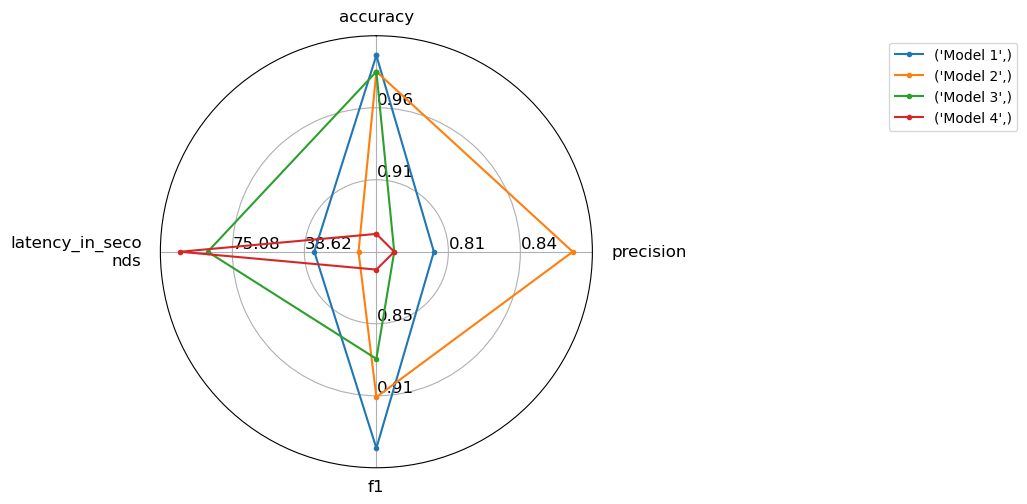

In [150]:
# 给变量 `plot` 赋值
plot = radar_plot(data=data, model_names=model_names)

# 5. 文本分类实例

## Step1 导入相关包

再次回顾：

* AutoTokenizer：自动匹配并实例化与模型对应的分词器，用于将文本 ↔ token ID 序列互转。

* AutoModelForSequenceClassification：根据预训练模型 ID 自动加载带分类头的 Transformer 模型，直接用于文本分类或回归任务。

* Trainer & TrainingArguments：Hugging Face 提供的高层训练 API：

  * Trainer 封装了训练、评估和预测流程，无需手写训练循环。

  * TrainingArguments 用于配置训练参数（学习率、批大小、日志频率、评估策略等）。

* load_dataset：从本地或 Hub 一行代码加载并管理数据集，返回 Dataset 或 DatasetDict 对象，支持分割、映射、筛选等操作。

In [151]:
# 从模块 transformers 导入内容
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
# 从模块 datasets 导入内容
from datasets import load_dataset

## Step2 加载数据集

* 从本地 CSV 文件加载训练集，并剔除 "review" 字段为空的样本，保证后续训练基于有效文本。

* 返回一个 Dataset 对象，仅包含完整评论数据。

In [152]:
# 给变量 `dataset` 赋值
dataset = load_dataset("csv", data_files="./06_cache/ChnSentiCorp_htl_all.csv", split="train")
# 给变量 `dataset` 赋值
dataset = dataset.filter(lambda x: x["review"] is not None)
# 执行操作
dataset

Dataset({
    features: ['label', 'review'],
    num_rows: 7765
})

## Step3 划分数据集

* train_test_split(test_size=0.1) 会随机将 dataset 拆分为 90% 的训练集和 10% 的测试集，返回一个包含 train 和 test 两个子集的 DatasetDict。

In [153]:
# 给变量 `datasets` 赋值
datasets = dataset.train_test_split(test_size=0.1)
# 执行操作
datasets

DatasetDict({
    train: Dataset({
        features: ['label', 'review'],
        num_rows: 6988
    })
    test: Dataset({
        features: ['label', 'review'],
        num_rows: 777
    })
})

## Step4 数据集预处理

* 加载分词器：AutoTokenizer.from_pretrained("hfl/rbt3") 实例化华为 RoBERTa-3 中文模型对应的分词器。

* 定义 process_function：对输入批量样本的 "review" 字段进行截断分词，并将原始 "label" 映射到新字段 "labels"。

* 批量映射 & 删除原始列：datasets.map(..., batched=True, remove_columns=...) 在保留 input_ids/attention_mask/labels 的同时，移除所有原始字段。

In [154]:
# 给变量 `tokenizer` 赋值
tokenizer = AutoTokenizer.from_pretrained("hfl/rbt3",cache_dir="./06_cache")

# 定义函数：process_function
def process_function(examples):
    # 给变量 `tokenized_examples` 赋值
    tokenized_examples = tokenizer(examples["review"], max_length=128, truncation=True)
    # 给变量 `tokenized_examples["labels"]` 赋值
    tokenized_examples["labels"] = examples["label"]
    # 执行操作
    return tokenized_examples

# 给变量 `tokenized_datasets` 赋值
tokenized_datasets = datasets.map(process_function, batched=True, remove_columns=datasets["train"].column_names)
# 执行操作
tokenized_datasets

tokenizer_config.json:   0%|          | 0.00/19.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/6988 [00:00<?, ? examples/s]

Map:   0%|          | 0/777 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 6988
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 777
    })
})

## Step5 创建模型

* 使用 AutoModelForSequenceClassification.from_pretrained("hfl/rbt3") 从本地或 Hugging Face Hub 加载华为 RoBERTa-3 (rbt3) 模型，并在其顶部附加一个线性分类头。

In [155]:
# 给变量 `model` 赋值
model = AutoModelForSequenceClassification.from_pretrained("hfl/rbt3",cache_dir="./06_cache")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at hfl/rbt3 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


* 显示模型配置

In [156]:
model.config

BertConfig {
  "_attn_implementation_autoset": true,
  "_name_or_path": "hfl/rbt3",
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "directionality": "bidi",
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 3,
  "output_past": true,
  "pad_token_id": 0,
  "pooler_fc_size": 768,
  "pooler_num_attention_heads": 12,
  "pooler_num_fc_layers": 3,
  "pooler_size_per_head": 128,
  "pooler_type": "first_token_transform",
  "position_embedding_type": "absolute",
  "transformers_version": "4.47.1",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 21128
}

## Step6 创建评估函数

* import evaluate：引入 Hugging Face 的评估库，用于加载和计算各种 NLP 评估指标。

* evaluate.load("accuracy")：加载“准确率”评估器，返回一个可调用的 Metric 对象，用于衡量分类模型的整体预测准确度。

* evaluate.load("f1")：加载“F1 值”评估器，返回可调用的 Metric 对象，用于计算精确率与召回率的调和平均。

In [157]:
# 导入模块：evaluate
import evaluate

# 给变量 `acc_metric` 赋值
acc_metric = evaluate.load("accuracy")
# 给变量 `f1_metric` 赋值
f1_metric = evaluate.load("f1")

* 输入：接收 Trainer 回调提供的 (predictions, labels) 元组，其中 predictions 是模型输出的 logits 数组，labels 是真实标签数组。
* 逻辑：先对 logits 做 argmax 转为类别索引，然后调用 acc_metric 计算准确率。

In [158]:
# 定义函数：eval_metric
def eval_metric(eval_predict):
    predictions, labels = eval_predict
    predictions = predictions.argmax(axis=-1)
    acc = acc_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels)
    acc.update(f1)
    return acc

## Step7 创建TrainingArguments

* 利用 TrainingArguments 统一管理训练与评估流程的超参数和策略，包括批大小、学习率、日志与检查点频率，以及模型保存与加载规则。

In [159]:
# 给变量 `train_args` 赋值
train_args = TrainingArguments(output_dir="./checkpoints",      # 输出文件夹
                               per_device_train_batch_size=64,  # 训练时的batch_size
                               per_device_eval_batch_size=128,  # 验证时的batch_size
                               logging_steps=10,                # log 打印的频率
                               evaluation_strategy="epoch",     # 评估策略
                               save_strategy="epoch",           # 保存策略
                               save_total_limit=3,              # 最大保存数
                               learning_rate=2e-5,              # 学习率
                               weight_decay=0.01,               # weight_decay
                               metric_for_best_model="f1",      # 设定评估指标
                               load_best_model_at_end=True)     # 训练完成后加载最优模型
train_args

c:\Users\kang\miniconda3\envs\pytorch\Lib\site-packages\transformers\training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


TrainingArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=False,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
dispatch_batches=None,
do_eval=True,
do_predict=False,
do_train=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_

## Step8 创建Trainer

* 模型与数据：将微调模型 model、训练集 train_dataset 和验证集 eval_dataset 结合在一起。

* 训练配置：使用之前定义的 train_args 管理训练超参数、评估与保存策略。

* 动态填充：通过 DataCollatorWithPadding(tokenizer=tokenizer) 实现批内按最长序列自动填充。

* 评估回调：compute_metrics=eval_metric 在每次评估结束后调用自定义函数，计算并记录指标（如准确率、F1）。

In [160]:
# 从模块 transformers 导入内容
from transformers import DataCollatorWithPadding
# 给变量 `trainer` 赋值
trainer = Trainer(model=model, 
                  args=train_args, 
                  train_dataset=tokenized_datasets["train"], 
                  eval_dataset=tokenized_datasets["test"], 
                  data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
                  compute_metrics=eval_metric)

## Step9 模型训练

* 启动 Trainer 的训练流程：包括数据批处理、前向与反向传播、梯度更新、周期性评估与模型检查点保存。

In [161]:
# 执行操作
trainer.train()

  0%|          | 0/330 [00:00<?, ?it/s]

{'loss': 0.5742, 'grad_norm': 2.133347272872925, 'learning_rate': 1.9393939393939395e-05, 'epoch': 0.09}
{'loss': 0.4638, 'grad_norm': 2.1655428409576416, 'learning_rate': 1.8787878787878792e-05, 'epoch': 0.18}
{'loss': 0.4461, 'grad_norm': 2.4300665855407715, 'learning_rate': 1.8181818181818182e-05, 'epoch': 0.27}
{'loss': 0.372, 'grad_norm': 2.3374757766723633, 'learning_rate': 1.7575757575757576e-05, 'epoch': 0.36}
{'loss': 0.3812, 'grad_norm': 7.101388931274414, 'learning_rate': 1.6969696969696972e-05, 'epoch': 0.45}
{'loss': 0.3576, 'grad_norm': 5.140263080596924, 'learning_rate': 1.6363636363636366e-05, 'epoch': 0.55}
{'loss': 0.3396, 'grad_norm': 3.6466426849365234, 'learning_rate': 1.575757575757576e-05, 'epoch': 0.64}
{'loss': 0.3315, 'grad_norm': 2.438438892364502, 'learning_rate': 1.5151515151515153e-05, 'epoch': 0.73}
{'loss': 0.3144, 'grad_norm': 5.265842914581299, 'learning_rate': 1.4545454545454546e-05, 'epoch': 0.82}
{'loss': 0.3286, 'grad_norm': 2.460259437561035, 'lea

  0%|          | 0/7 [00:00<?, ?it/s]

{'eval_loss': 0.301980197429657, 'eval_accuracy': 0.8687258687258688, 'eval_f1': 0.9064220183486239, 'eval_runtime': 0.2793, 'eval_samples_per_second': 2782.05, 'eval_steps_per_second': 25.064, 'epoch': 1.0}
{'loss': 0.2966, 'grad_norm': 4.020718097686768, 'learning_rate': 1.2727272727272728e-05, 'epoch': 1.09}
{'loss': 0.2932, 'grad_norm': 2.6295673847198486, 'learning_rate': 1.2121212121212122e-05, 'epoch': 1.18}
{'loss': 0.2681, 'grad_norm': 2.8998146057128906, 'learning_rate': 1.1515151515151517e-05, 'epoch': 1.27}
{'loss': 0.2546, 'grad_norm': 4.034562587738037, 'learning_rate': 1.0909090909090909e-05, 'epoch': 1.36}
{'loss': 0.2124, 'grad_norm': 3.420553684234619, 'learning_rate': 1.0303030303030304e-05, 'epoch': 1.45}
{'loss': 0.3015, 'grad_norm': 6.4463043212890625, 'learning_rate': 9.696969696969698e-06, 'epoch': 1.55}
{'loss': 0.2508, 'grad_norm': 5.077640533447266, 'learning_rate': 9.090909090909091e-06, 'epoch': 1.64}
{'loss': 0.2805, 'grad_norm': 4.136011123657227, 'learni

  0%|          | 0/7 [00:00<?, ?it/s]

{'eval_loss': 0.27298828959465027, 'eval_accuracy': 0.888030888030888, 'eval_f1': 0.9180018850141376, 'eval_runtime': 0.2696, 'eval_samples_per_second': 2882.186, 'eval_steps_per_second': 25.966, 'epoch': 2.0}
{'loss': 0.1934, 'grad_norm': 3.5397205352783203, 'learning_rate': 6.060606060606061e-06, 'epoch': 2.09}
{'loss': 0.2406, 'grad_norm': 4.432567119598389, 'learning_rate': 5.4545454545454545e-06, 'epoch': 2.18}
{'loss': 0.2039, 'grad_norm': 3.223844051361084, 'learning_rate': 4.848484848484849e-06, 'epoch': 2.27}
{'loss': 0.2449, 'grad_norm': 2.7607085704803467, 'learning_rate': 4.242424242424243e-06, 'epoch': 2.36}
{'loss': 0.2393, 'grad_norm': 7.126715660095215, 'learning_rate': 3.6363636363636366e-06, 'epoch': 2.45}
{'loss': 0.255, 'grad_norm': 4.000599384307861, 'learning_rate': 3.0303030303030305e-06, 'epoch': 2.55}
{'loss': 0.2245, 'grad_norm': 2.141286849975586, 'learning_rate': 2.4242424242424244e-06, 'epoch': 2.64}
{'loss': 0.2477, 'grad_norm': 3.1878421306610107, 'learni

  0%|          | 0/7 [00:00<?, ?it/s]

{'eval_loss': 0.2665177881717682, 'eval_accuracy': 0.8918918918918919, 'eval_f1': 0.9204545454545454, 'eval_runtime': 0.2797, 'eval_samples_per_second': 2777.533, 'eval_steps_per_second': 25.023, 'epoch': 3.0}
{'train_runtime': 24.2318, 'train_samples_per_second': 865.143, 'train_steps_per_second': 13.618, 'train_loss': 0.2910509806690794, 'epoch': 3.0}


TrainOutput(global_step=330, training_loss=0.2910509806690794, metrics={'train_runtime': 24.2318, 'train_samples_per_second': 865.143, 'train_steps_per_second': 13.618, 'total_flos': 351909933963264.0, 'train_loss': 0.2910509806690794, 'epoch': 3.0})

## Step10 模型评估

* 调用 Trainer.evaluate() 方法，将微调好的模型在指定的测试集 tokenized_datasets["test"] 上运行前向计算并收集评估指标。

* 返回一个字典，包含如损失值 (loss)、以及通过 compute_metrics 计算得到的准确率、F1 等指标。

In [162]:
# 执行操作
trainer.evaluate(tokenized_datasets["test"])

  0%|          | 0/7 [00:00<?, ?it/s]

{'eval_loss': 0.2665177881717682,
 'eval_accuracy': 0.8918918918918919,
 'eval_f1': 0.9204545454545454,
 'eval_runtime': 0.4402,
 'eval_samples_per_second': 1765.06,
 'eval_steps_per_second': 15.901,
 'epoch': 3.0}

## Step11 模型预测

* trainer.predict(...) 会将模型置于评估模式，对指定数据集逐批执行前向计算，返回一个 PredictionOutput 对象，包含：

* predictions：形状为 (num_examples, num_labels) 的 logits 数组

* label_ids：真实标签数组

* metrics：与 evaluate() 类似计算的评估指标（如 loss、accuracy、f1 等）

In [163]:
# 执行操作
trainer.predict(tokenized_datasets["test"])

  0%|          | 0/7 [00:00<?, ?it/s]

PredictionOutput(predictions=array([[-2.837693 ,  2.2805715],
       [-1.8394014,  1.3075008],
       [-2.979803 ,  2.1983335],
       ...,
       [-1.5946852,  1.1898146],
       [ 1.6256775, -1.1740549],
       [-2.06818  ,  1.7758195]], dtype=float32), label_ids=array([1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0,
    

* 导入 pipeline：Hugging Face 提供的高层推理接口，简化常用任务（如分类、生成、填空等）的调用。

* 设定 id2label：将整数标签映射到中文可读字符串，写入 model.config.id2label，以便 pipeline 输出时自动使用对应的文本标签。

* 实例化 pipeline：通过 "text-classification" 任务名与指定的模型、分词器和设备，构建一个完整的推理流水线对象 pipe。

In [164]:
# 从模块 transformers 导入内容
from transformers import pipeline

id2_label = id2_label = {0: "差评！", 1: "好评！"}
model.config.id2label = id2_label
pipe = pipeline("text-classification", model=model, tokenizer=tokenizer, device=0)

Device set to use cuda:0


* 将原始中文句子 sen 传入提前创建好的 text-classification Pipeline pipe，自动完成：

1. 分词与编码（Tokenizer）

2. 模型前向推理（Model）

3. 标签映射（id2label）

4. 分数归一化（Softmax）

In [165]:
# 给变量 `sen` 赋值
sen = "我觉得不错！"
pipe(sen)

[{'label': '好评！', 'score': 0.9856858849525452}]